# 1. A single site

LUMPREM is a lumped-parameter recharge model. One site is a soil-moisture
store, filled by rainfall and irrigation and emptied by evaporation and
drainage, stepped one day at a time. Drainage and macropore flow leaving the
store are delayed before they reach the water table, and an optional second
store can sit between the two. The output is a daily water budget, including
the recharge a groundwater model needs.

This notebook covers one site from start to finish:

1. forcing, and the rules that fill its gaps;
2. building and running a model;
3. reading the results, and choosing when they are reported;
4. drainage delays, the lower store and the water-table conversion;
5. what happens when the solver does not converge;
6. running many parameter sets at once, which leads into the spatial
   notebooks.

Units are whatever the forcing is in. The example climate is in metres per
day, so every volume below is a depth in metres.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import lumpyrem as lr

## 1. Forcing

The example climate is ten years of daily rainfall and potential evaporation
for Monto, Queensland (SILO patched-point data; see `data/README.md`). Rain
falls mostly in summer, and potential evaporation is nearly three times the
rainfall.

In [2]:
clim = pd.read_csv("data/climate.csv", index_col="date", parse_dates=True)
clim.head()

,rainfall,pot_evap
date,,
1990-01-31,0.0,0.0070
1990-02-01,0.0,0.0056
1990-02-02,0.0,0.0086
1990-02-03,0.0,0.0096
1990-02-04,0.0,0.0114


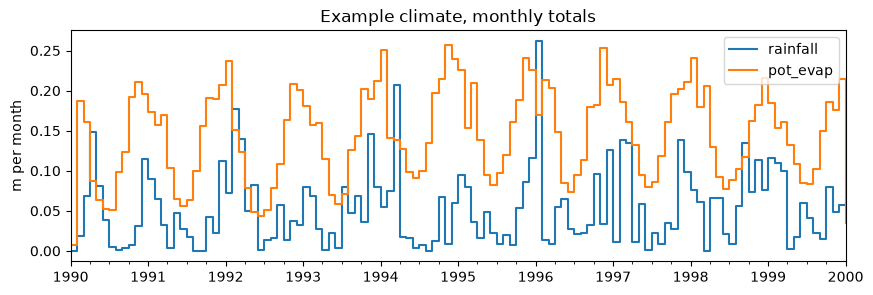

In [3]:
monthly = clim.resample("MS").sum()
ax = monthly.plot(figsize=(10, 3), drawstyle="steps-post")
ax.set_ylabel("m per month")
ax.set_xlabel("")
ax.set_title("Example climate, monthly totals");

A `Forcing` holds seven variables. Three are required: `rainfall`,
`pot_evap` and `veg_gamma`, the curvature of the evaporation response. The
rest have defaults. Any variable can be a series or a plain number; a number
is constant over the whole run.

In [4]:
forcing = lr.Forcing.from_dataframe(clim, veg_gamma=2.0)
forcing.span

(Timestamp('1990-01-31 00:00:00'), Timestamp('2000-01-05 00:00:00'))

### Gap-filling rules

Forcing does not have to be daily. Each variable carries a rule that extends
its listed values to the days in between. The defaults are those of
`lumprem2.f`: rain is zero-filled, because rain does not persist; evaporation
and irrigation are held as steps; vegetation is interpolated.

In [5]:
forcing.fill

{'rainfall': <Fill.ZERO: 'zero'>,
 'pot_evap': <Fill.FORWARD: 'forward'>,
 'crop_factor': <Fill.INTERPOLATE: 'interpolate'>,
 'veg_gamma': <Fill.INTERPOLATE: 'interpolate'>,
 'irrigate': <Fill.FORWARD: 'forward'>,
 'gw_irrig_frac': <Fill.FORWARD: 'forward'>,
 'pot_evap_lower': <Fill.FORWARD: 'forward'>}

A crop factor, for example, is rarely known daily. Here it is listed twice a
year, high in the wet summer and low in the dry winter, and interpolated
between. `NaN` means "not listed on this day", so the sparse series can share
a frame with the daily climate.

The listed dates run from 15 January 1990 to 15 January 2000, which is
wider than the climate. A run spans the first to last listed date unless told
otherwise, so the window is given explicitly from here on.

In [6]:
listed = pd.date_range("1990-01-01", "2000-01-01", freq="6MS") + pd.Timedelta(days=14)
crop_factor = pd.Series(np.where(listed.month == 1, 1.0, 0.6), index=listed,
                        name="crop_factor")
frame = clim.join(crop_factor, how="outer")

window = dict(start=clim.index[0], end=clim.index[-1])
forcing = lr.Forcing.from_dataframe(frame, veg_gamma=2.0)
frame.loc["1990-01-10":"1990-02-03"]

,rainfall,pot_evap,crop_factor
date,,,
1990-01-15,NaN,NaN,1.0
1990-01-31,0.0,0.0070,NaN
1990-02-01,0.0,0.0056,NaN
1990-02-02,0.0,0.0086,NaN
1990-02-03,0.0,0.0096,NaN


`to_daily` shows exactly what the model will see. Changing the crop factor's
rule to `"forward"` holds each value as a step instead.

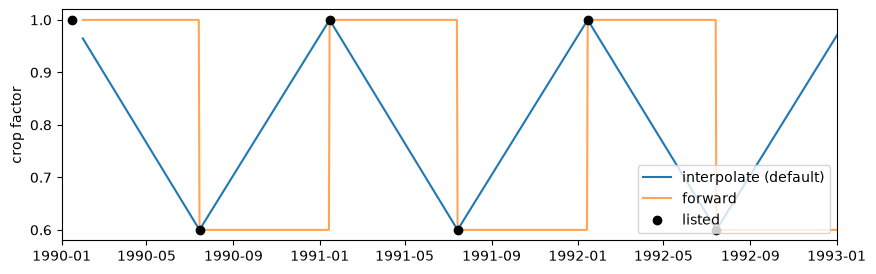

In [7]:
stepped = lr.Forcing.from_dataframe(frame, veg_gamma=2.0, fill={"crop_factor": "forward"})
days = pd.date_range(window["start"], window["end"], freq="D")

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(days, forcing.to_daily(**window)["crop_factor"], label="interpolate (default)")
ax.plot(days, stepped.to_daily(**window)["crop_factor"], label="forward", alpha=0.7)
ax.plot(crop_factor.index, crop_factor, "ko", label="listed")
ax.set_xlim(pd.Timestamp("1990-01-01"), pd.Timestamp("1993-01-01"))
ax.set_ylabel("crop factor")
ax.legend(loc="lower right");

Forcing the model cannot use is refused when it is built or resolved, with
the day that broke it: negative rain, a zero `veg_gamma`, an `irrigate` flag
that is not 0 or 1, or an unknown column name.

In [8]:
try:
    lr.Forcing.from_dataframe(clim.rename(columns={"rainfall": "rain"}), veg_gamma=2.0)
except lr.ForcingError as err:
    print(err)

unknown forcing column(s) ['rain']; known names are ['rainfall', 'pot_evap', 'crop_factor', 'veg_gamma', 'irrigate', 'gw_irrig_frac', 'pot_evap_lower']


## 2. A model

A `Model` is built from typed parameter objects. The one required part is the
upper store:

| parameter | meaning |
|---|---|
| `maxvol` | storage at field capacity (m) |
| `ks`, `m`, `l` | van Genuchten–Mualem drainage: saturated rate (m/day), shape, pore connectivity |
| `mflowmax` | cap on macropore flow (m/day); flow above the cap becomes runoff |
| `irrigvolfrac` | on irrigation days, top the store up to this fraction of `maxvol` |
| `rdelay`, `mdelay` | days of delay on drainage and on macropore flow |

Each object validates itself on construction, and is stricter than the
Fortran: where `lumprem2.f` silently clamps a value into range, this refuses
it.

In [9]:
upper = lr.UpperStore(maxvol=0.15, ks=0.2, m=0.5, l=0.5, rdelay=30, mdelay=1)
model = lr.Model(upper=upper, initial=lr.InitialState(vol=0.075))
model

Model(upper=UpperStore(maxvol=0.15, ks=0.2, m=0.5, l=0.5, mflowmax=0.0, irrigvolfrac=0.0, rdelay=30.0, mdelay=1.0), lower=None, elevation=None, solver=Solver(nstep=5, mxiter=100, tol=1e-06, on_nonconvergence='warn'), initial=InitialState(vol=0.075, vol_lower=0.0, drain_buffer=(0.0,), macro_buffer=(0.0,)))

In [10]:
try:
    lr.UpperStore(maxvol=0.15, ks=0.2, m=0.0, l=0.5)
except lr.ParameterError as err:
    print(err)
    print("field:", err.field, "| value:", err.value)

UpperStore.m must be > 0 (the drainage law takes 1/m); got 0.0
field: m | value: 0.0


`run` takes the forcing and a reporting schedule. `times="MS"` reports at the
start of every month.

In [11]:
results = model.run(forcing, times="MS", **window)
results

<Results: 120 output times, 1990-01-31 to 2000-01-01, converged>

## 3. Results

`results.df` is a DataFrame with one row per output time. Two conventions
matter:

- **Row 0 is the initial state**, at the start of the run. Its volumes are
  the initial conditions and its fluxes are zero.
- **Each row labels the end of its interval.** Flux columns are totals over
  the days since the previous row; volume columns are states at the row's own
  time. The row stamped 1 March holds February's totals. This is how a
  MODFLOW stress period reads.

In [12]:
cols = ["rainfall", "evap_upper", "total_rech", "runoff", "vol_upper", "vol_drain"]
results.df[cols].head()

,rainfall,evap_upper,total_rech,runoff,vol_upper,vol_drain
time,,,,,,
1990-01-31,0.0000,0.000000,0.000000,0.0,0.075000,0.000000
1990-02-01,0.0000,0.003746,0.000000,0.0,0.069158,0.002096
1990-03-01,0.0191,0.052995,0.000000,0.0,0.029683,0.007675
1990-04-01,0.0682,0.033643,0.007711,0.0,0.058907,0.005297
1990-05-01,0.1481,0.040761,0.005297,0.0,0.061372,0.104875


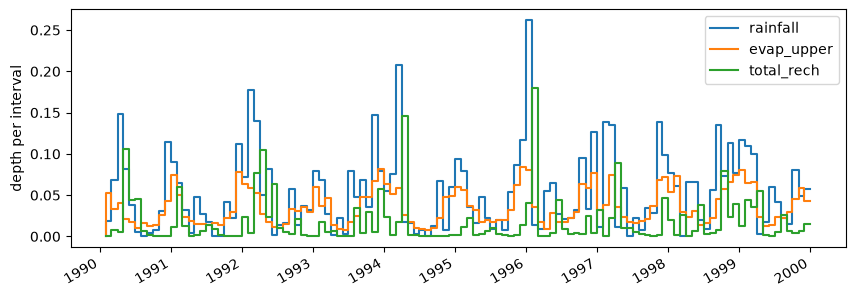

In [13]:
results.plot(["rainfall", "evap_upper", "total_rech"], figsize=(10, 3.5),
             drawstyle="steps-pre");

The `balance` column is the kernel's own residual for each interval: inflow
minus outflow minus the change in every store and delay buffer.
`balance_error()` reports the worst of them.

In [14]:
results.balance_error()

2.220446049250313e-16

### Choosing when to report

`times` sets the reporting schedule, not the time step, which is always a
day. It takes:

- `None` — every day;
- a pandas frequency string — `"MS"`, `"YS"`, `"W"`, `"QS"`, ...;
- a list of dates — observation dates, or stress-period ends;
- a list of integers — 1-based simulation days, as in the Fortran.

Totals do not depend on the schedule, only how they are divided up.

In [15]:
daily = model.run(forcing, times=None, **window)
yearly = model.run(forcing, times="YS", **window)
pd.Series({
    "daily": daily.df["total_rech"].sum(),
    "monthly": results.df["total_rech"].sum(),
    "yearly": yearly.df["total_rech"].sum(),
}, name="total recharge (m)")

daily      2.106866
monthly    2.106738
yearly     2.106738
Name: total recharge (m), dtype: float64

The monthly and yearly totals agree. The daily total is slightly larger
because the run carries on to 5 January 2000, past the last month or year
start, and only a daily schedule reports those five days.

An annual water budget follows from `times="YS"`. Since each row labels the
end of its interval, the row stamped 1 January 1991 is 1990 — here a part
year, since the run starts on 31 January.

In [16]:
budget = yearly.df[["rainfall", "evap_upper", "runoff", "total_rech", "del_vol_upper"]]
budget = budget.iloc[1:].set_axis(yearly.times[1:].year - 1, axis=0).rename_axis("year")
budget.assign(rech_frac=budget["total_rech"] / budget["rainfall"]).round(3)

,rainfall,evap_upper,runoff,total_rech,del_vol_upper,rech_frac
year,,,,,,
1990,0.518,0.292,0.0,0.217,0.000,0.418
1991,0.459,0.371,0.0,0.119,-0.044,0.259
1992,0.694,0.386,0.0,0.336,-0.005,0.484
1993,0.659,0.461,0.0,0.163,0.012,0.247
1994,0.531,0.373,0.0,0.195,-0.016,0.368
1995,0.587,0.458,0.0,0.077,0.014,0.131
1996,0.763,0.456,0.0,0.316,-0.002,0.414
1997,0.686,0.455,0.0,0.222,0.022,0.324
1998,0.754,0.506,0.0,0.249,0.006,0.330


Explicit dates work the same way; each row is the total since the one
before.

In [17]:
visits = pd.to_datetime(["1992-03-01", "1994-11-15", "1997-06-30", "1999-12-01"])
model.run(forcing, times=visits, **window).df[["total_rech", "vol_upper"]]

,total_rech,vol_upper
time,,
1990-01-31,0.000000,0.075000
1992-03-01,0.362864,0.078757
1994-11-15,0.664101,0.023335
1997-06-30,0.558739,0.032424
1999-12-01,0.506344,0.032669


## 4. Delays, a lower store and the water table

### Drainage delay

`rdelay` holds drainage back for that many days before releasing it as
recharge. It is a pure lag: recharge arrives later but is not spread out,
except that a fractional delay splits each day's water between two
neighbouring days. Water in transit is the `vol_drain` column. There is no
upper limit; `lumprem2.f` capped delays at 498 days without saying so.

`Model.with_` copies a model with some fields replaced, which suits a quick
sensitivity run.

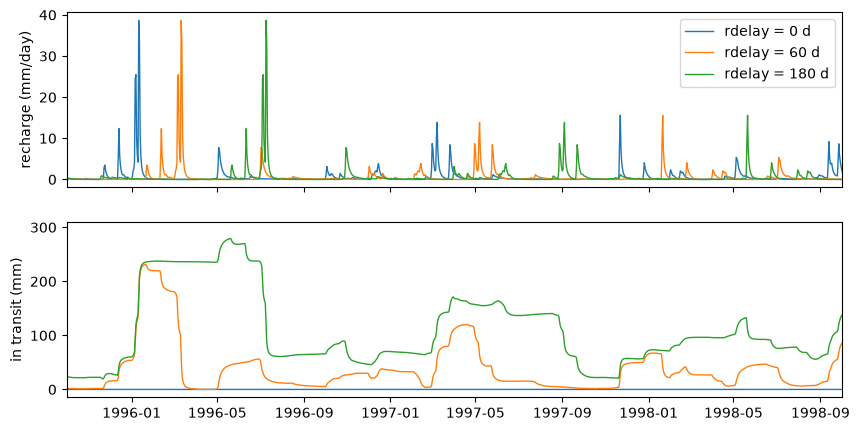

In [18]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
for rdelay in (0, 60, 180):
    run = model.with_(upper=lr.UpperStore(maxvol=0.15, ks=0.2, m=0.5, l=0.5,
                                          rdelay=rdelay, mdelay=1)).run(
        forcing, times=None, **window)
    ax1.plot(run.times, run.df["total_rech"] * 1000, label=f"rdelay = {rdelay} d", lw=1)
    ax2.plot(run.times, run.df["vol_drain"] * 1000, lw=1)
ax1.set_ylabel("recharge (mm/day)")
ax2.set_ylabel("in transit (mm)")
ax1.legend()
ax1.set_xlim(pd.Timestamp("1995-10-01"), pd.Timestamp("1998-10-01"));

### A lower store and a water-table elevation

A `LowerStore` adds a second store below the root zone, drained by the same
kind of law. With one present, the drainage delay applies on the way *into*
it, and only macropore flow is delayed on its way to the water table.

`VolumeToElevation` turns a store's volume into an elevation,
`offset + factor1 * v + factor2 * v ** power`, and reports
`depth_to_water = datum - elevation`. Here it is driven by the lower store.

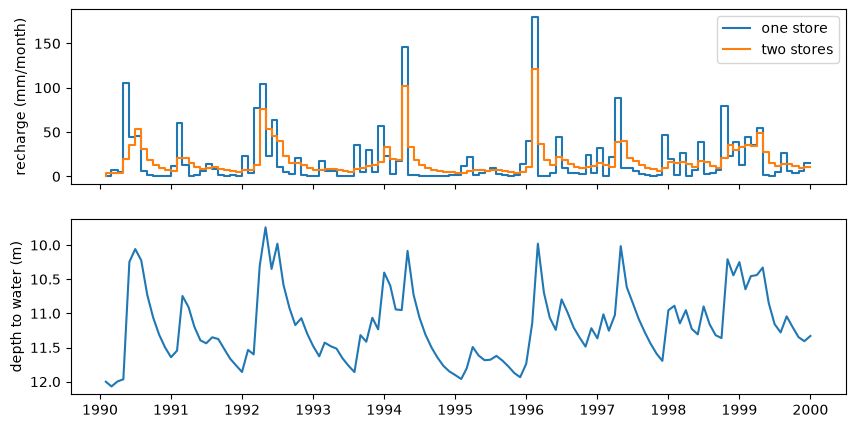

In [19]:
two_store = model.with_(
    lower=lr.LowerStore(maxvol=0.3, gamma=1.0, ks=0.01, m=0.5, l=0.5),
    elevation=lr.VolumeToElevation(offset=95.0, factor1=20.0, factor2=0.0, power=1.0,
                                   datum=110.0, bucket="lower"),
    initial=lr.InitialState(vol=0.075, vol_lower=0.15),
)
two = two_store.run(forcing, times="MS", **window)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
ax1.step(results.times, results.df["total_rech"] * 1000, label="one store")
ax1.step(two.times, two.df["total_rech"] * 1000, label="two stores")
ax1.set_ylabel("recharge (mm/month)")
ax1.legend()
ax2.plot(two.times, two.df["depth_to_water"])
ax2.invert_yaxis()
ax2.set_ylabel("depth to water (m)");

## 5. Convergence

Each day is split into `Solver.nstep` sub-steps, and each sub-step is solved
by Picard iteration. The drainage law is steep as the store approaches full
whenever `m < 1`, so a small, fast-draining store with a small `m` can fail
to converge. The Fortran printed a message and carried on. Here a run that
does not converge warns, and the results say so.

In [20]:
flashy = lr.Model(upper=lr.UpperStore(maxvol=0.03, ks=2.0, m=0.15, l=0.5))
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    bad = flashy.run(forcing, times="MS", **window)
print(caught[0].message)
bad, bad.nonconverged_upper

581 upper-store and 0 lower-store sub-step(s) hit mxiter=100 without meeting tol=1e-06. Results are returned but are not solutions. The drainage law has an unbounded slope as a store approaches full whenever m < 1, so raising nstep can make this worse rather than better. Try a larger m, a smaller ks, or a looser tol.


(<Results: 120 output times, 1990-01-31 to 2000-01-01, NOT converged (581 sub-steps)>,
 581)

The balance still closes, so a small `balance_error()` is not evidence of
convergence; `results.converged` is.

In [21]:
bad.balance_error(), bad.converged

(1.249000902703301e-16, False)

`Solver(on_nonconvergence="raise")` turns the warning into an error, which
suits a calibration that should reject such parameter sets rather than fit
to them.

In [22]:
strict = flashy.with_(solver=lr.Solver(on_nonconvergence="raise"))
try:
    strict.run(forcing, times="MS", **window)
except lr.ModelError as err:
    print(str(err)[:120], "...")

the run did not converge: 581 upper-store and 0 lower-store sub-step(s) hit mxiter=100 without meeting tol=1e-06. The dr ...


## 6. Two engines, and many runs at once

There are two kernels. The compiled one, built with Numba, is used whenever
Numba is installed; a pure-Python one is used otherwise. They are held to
exact equality, so the choice affects speed only.

In [23]:
python_run = model.run(forcing, times="MS", engine="python", **window)
np.array_equal(python_run.values, results.values, equal_nan=True)

True

A `ModelGrid` runs many independent models together, in parallel on the
compiled kernel. Its main use is spatial — one model per cell of a
groundwater model, covered in the next two notebooks — but it is also a quick
way to run a parameter sweep. Any parameter given as an array varies from
model to model; a number is shared.

In [24]:
ks = np.logspace(-2.5, 0.5, 60)
sweep = lr.ModelGrid.from_arrays(
    upper=dict(maxvol=0.15, ks=ks, m=0.5, l=0.5, rdelay=30, mdelay=1),
    initial=dict(vol=0.075),
)
sweep_results = sweep.run(forcing, times="YS", **window)
sweep_results

/var/folders/wp/1fxcqz4j67z25cs7_p417_h40000gn/T/ipykernel_24374/3329964516.py:6: ConvergenceWarning: 1 upper-store and 0 lower-store sub-step(s) across 1 of 60 cells (first: 31) hit mxiter=100 without meeting tol=1e-06. Results are returned but are not solutions. The drainage law has an unbounded slope as a store approaches full whenever m < 1, so raising nstep can make this worse rather than better. Try a larger m, a smaller ks, or a looser tol.
  sweep_results = sweep.run(forcing, times="YS", **window)


<GridResults: 60 cells x 10 output times, 1990-01-31 to 2000-01-01, 1 cell(s) NOT converged>

One of the sixty runs did not converge, and the warning names it. The counts
are per model in `nonconverged`, upper store then lower store: here a single
sub-step, out of about 18,000 in the run. Whether that matters is a
judgement; this one persists at `mxiter=500` and at `nstep=10`, and the curve
below is smooth through it. In a spatial run the same check says which cells
to look at.

In [25]:
failed = sweep_results.nonconverged_cells
failed, sweep_results.nonconverged[failed], ks[failed].round(3)

([31], array([[1, 0]]), array([0.119]))

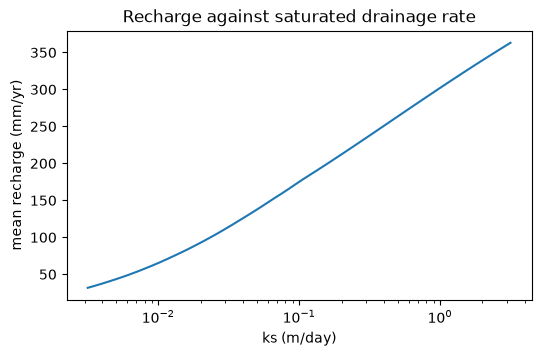

In [26]:
nyears = (window["end"] - window["start"]).days / 365.25
mean_rech = sweep_results["total_rech"].sum() / nyears

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.semilogx(ks, mean_rech * 1000)
ax.set_xlabel("ks (m/day)")
ax.set_ylabel("mean recharge (mm/yr)")
ax.set_title("Recharge against saturated drainage rate");

Each model in a grid reproduces exactly what it would give when run alone.

In [27]:
k = 30
alone = sweep[k].run(forcing, times="YS", **window)
np.array_equal(alone.values, sweep_results.cell(k).values, equal_nan=True)

True

**Next:** [02_spatial_parameters.ipynb](02_spatial_parameters.ipynb) builds
a grid whose parameters vary across a landscape of soils and land uses.